# Assignment 1 2AMM10 2025-2026

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [3]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [4]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

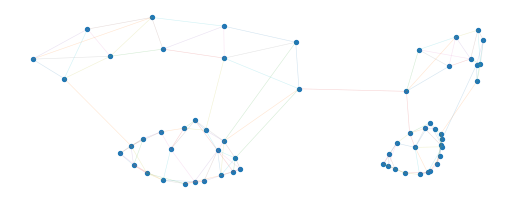

In [5]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

# Task 2

In [6]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

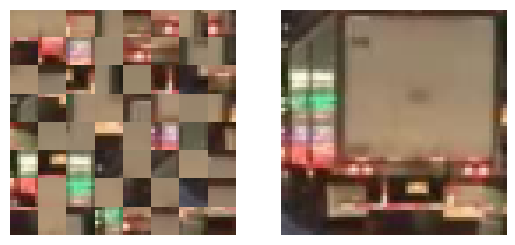

In [ ]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)


### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [7]:
class Lambda(nn.Module):
    def __init__(self, func, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.func = func
    
    def forward(self, x):
        return self.func(x)

In [8]:
# We used a vision transformer architecture for learning image representations from
# patch tokens. This architecture was chosen as the task involves classifying corrupetd images
# with shuffled patches. Since the model processes the image as a sequential projection of patches,
# it is perfectly suited for the given task with minimal architectural changes.
class VisionTransformer(nn.Module):
    def __init__(self, n_classes, patch_size = 8, embedding_dim = 64, num_heads = 4, mlp_dim = 128, depth = 4, dropout = 0.3):
        super().__init__()
        # This layer transforms patches into embeddings using a convolution that takes a kernel_size of
        # (patch_size x patch_size). The resulting embeddings are flattened because the transformer
        # expects 1 dimensional vector inputs. 
        self.patch_embedding = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=embedding_dim, kernel_size=patch_size, stride=patch_size),
            nn.Flatten(start_dim=-2),
            Lambda(lambda x: x.transpose(-2, -1)),
        )

        # Learnable CLS token added to the patch sequence. After self-attention,
        # its final representation is used as the global image representation for classification.
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim) * 0.02)

        # Single Transformer block used to model relationships between patch tokens. It uses self-attention with multiple heads to create
        # multiple relations between tokens, followed by an MLP (which is a small neural network that processes each token representation independently).
        transformer_layer = nn.TransformerEncoderLayer(d_model=embedding_dim, nhead=num_heads, dim_feedforward=mlp_dim, dropout=dropout, activation="gelu", norm_first=True, batch_first=True)

        self.transformer = nn.TransformerEncoder(transformer_layer, num_layers=depth)

        # Final classification layer -> Outputs logits
        self.classification = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, n_classes)
        )
    
    def forward(self, x):
        patch_embedding = self.patch_embedding(x)

        batch_size = patch_embedding.size(0)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        patches = torch.cat([cls_tokens, patch_embedding], dim=1)

        output = self.transformer(patches)

        cls_output = output[:, 0]

        return self.classification(cls_output)


In [9]:
import torch
import numpy as np
import tqdm
import copy
import matplotlib.pyplot as plt

# Model trainer that uses a checkpointing strategy to keep the best performing
# model during training. 
class VisionTransformerTrainer():
    def __init__(
        self,
        model: torch.nn.Module,
        device: torch.device,
        criterion: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        training_DataLoader: torch.utils.data.DataLoader,
        validation_DataLoader: torch.utils.data.DataLoader,
        epochs: int,
        criterion_validation: torch.nn.Module = None,
        checkpoint: bool = False,
        checkpoint_path: str = "best_vit_model.pt",
    ):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.training_DataLoader = training_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.device = device
        self.epochs = epochs
        self.checkpoint = checkpoint
        if self.checkpoint:
            self.checkpoint_path = checkpoint_path

        if criterion_validation is None:
            self.criterion_validation = criterion
        else:
            self.criterion_validation = criterion_validation

    def run_trainer(self):
        best_val_acc = 0.0
        best_val_loss = float("inf")
        best_epoch = 0
        best_model_state = None

        for epoch in tqdm.tqdm(range(self.epochs)):
            self.model.train()

            train_losses = []
            correct = 0
            total = 0

            for batch in self.training_DataLoader:
                x, label_x = batch

                input = x.to(self.device)
                label_target = label_x.to(self.device).long()

                self.optimizer.zero_grad()

                out = self.model(input)
                loss = self.criterion(out, label_target)

                loss.backward()
                self.optimizer.step()

                train_losses.append(loss.item())

                preds = out.argmax(dim=1)
                correct += (preds == label_target).sum().item()
                total += label_target.size(0)

            train_loss = np.mean(train_losses)
            train_acc = correct / total

            self.model.eval()

            valid_losses = []
            valid_correct = 0
            valid_total = 0

            with torch.no_grad():
                for batch in self.validation_DataLoader:
                    x, label_x = batch

                    input = x.to(self.device)
                    label_target = label_x.to(self.device).long()

                    out = self.model(input)
                    loss = self.criterion_validation(out, label_target)

                    valid_losses.append(loss.item())

                    preds = out.argmax(dim=1)
                    valid_correct += (preds == label_target).sum().item()
                    valid_total += label_target.size(0)

            val_loss = np.mean(valid_losses)
            val_acc = valid_correct / max(valid_total, 1)

            if self.checkpoint and val_acc > best_val_acc:
                best_val_acc = val_acc
                best_val_loss = val_loss
                best_epoch = epoch + 1

                best_model_state = copy.deepcopy(self.model.state_dict())

                torch.save({
                    "epoch": best_epoch,
                    "model_state_dict": self.model.state_dict(),
                    "optimizer_state_dict": self.optimizer.state_dict(),
                    "val_acc": best_val_acc,
                    "val_loss": best_val_loss,
                }, self.checkpoint_path)

            print(
                f"EPOCH: {epoch + 1:0>{len(str(self.epochs))}}/{self.epochs} "
                f"LOSS: {train_loss:.4f} "
                f"VAL-LOSS: {val_loss:.4f}"
            )
            print(f"ACCURACY: {train_acc:.4f}")
            print(f"VAL-ACCURACY: {val_acc:.4f}")

        print(f"Training finished.")

        if self.checkpoint and best_model_state is not None :
            self.model.load_state_dict(best_model_state)
            print(f"Best model loaded from epoch: {best_epoch} with val accuracy: {best_val_acc}.")

    def load_last_model(self):
        checkpoint = torch.load(self.checkpoint_path, map_location=DEVICE, weights_only=False)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        print("Last model loaded.")


In [10]:
train_task2 = False # Set to false for loading saved model
infer_task2 = False  

In [13]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=Compose([Resize((64, 64)), ToTensor(), Normalize((0.5), (0.5))]), 
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), Normalize((0.5), (0.5))]), 
)

validate_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8), Normalize((0.5), (0.5))]), 
)

In [14]:
from torch.utils.data import DataLoader

train_data_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_data_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

patch_size = train_dataset[0][0].size(-1) // 8
n_classes = len(set(train_dataset.labels))

# Based on experimental observations, I arrived at the conclusion that a smaller model performs better for the given task. 
# Larger models tend to overfit, most likely due to the small size of the dataset. Another measure used to reduce overfitting
# is increasing weight decay and dropout. Weight decay penalizes large model weights and dropout randomly disables part of
# the activations during training. Further experiments could be performed to arrive at a better model, but as of its current
# configuration, this model achieves a training accuracy of ~0.60 and test accuracy between 0.45 and 0.5.
model = VisionTransformer(n_classes=n_classes, patch_size=patch_size, embedding_dim=64, num_heads=4, mlp_dim=256, depth=2, dropout=0.25).to(DEVICE)

# This loss function is used as the model outputs logits. It is also the standard criterion for single-labele multi-class classification.
criterion = nn.CrossEntropyLoss()

# AdamW optimizer with a small learning rate for stable training.
# Weight decay provides regularization to reduce overfitting.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=2e-3)


trainer = VisionTransformerTrainer(
    model,
    DEVICE,
    criterion,
    optimizer,
    train_data_loader,
    test_data_loader,
    epochs=100,
    checkpoint_path="best_vit_model.pt",
    checkpoint=True
)

if train_task2:
    trainer.run_trainer()
else:
    trainer.load_last_model()


Last model loaded.


/var/folders/xl/mxt4qdkx3m93j_vbz6xh2_880000gn/T/ipykernel_61310/1856627284.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(transformer_layer, num_layers=depth)


In [15]:
import torch
# Per-class metrics are: precision and recall
# Agregated metrics are: macro precision and macro recall

def evaluate_per_class(model, loader, class_names, labels, visualize = False):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE).long()

            out = model(x)
            preds = out.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    per_class_precision = []
    per_class_recall = []

    for label in set(labels):
        tp = np.sum((all_preds == label) & (all_labels == label))
        fp = np.sum((all_preds == label) & (all_labels != label))
        fn = np.sum((all_preds != label) & (all_labels == label))
    
        if tp + fp == 0:
            precision = 0.0
        else:
            precision = tp / (tp + fp)

        if tp + fn == 0:
            recall = 0.0
        else:
            recall = tp / (tp + fn)

        per_class_precision.append(precision)
        per_class_recall.append(recall)

        if visualize:
            print(f"{class_names[label]:15s} | Precision: {precision:.4f} | Recall: {recall:.4f}")

    # Visualization in a single figure
    if visualize:

        x = np.arange(n_classes)
        width = 0.35

        plt.figure(figsize=(12, 6))

        plt.bar(x - width / 2, per_class_precision, width, label="Precision")
        plt.bar(x + width / 2, per_class_recall, width, label="Recall")

        plt.xticks(x, class_names)
        plt.ylim(0, 1)
        plt.ylabel("Score")
        plt.title("Per-class Precision and Recall")
        plt.legend()
        plt.tight_layout()
        plt.savefig("per_class_precision_recall.png", dpi=300, bbox_inches="tight")
        plt.show()
    
    return per_class_precision, per_class_recall


def agregate_per_class_metrics(per_class_precision, per_class_recall):
    precision_macro = np.mean(per_class_precision)
    recall_macro = np.mean(per_class_recall)

    print()
    print(f"Macro precision: {precision_macro:.4f}")
    print(f"Macro recall:    {recall_macro:.4f}")

    return precision_macro, recall_macro

   

person          | Precision: 0.5517 | Recall: 0.5333
rider           | Precision: 0.4444 | Recall: 0.5333
car             | Precision: 0.4000 | Recall: 0.5333
truck           | Precision: 0.3684 | Recall: 0.2333
bus             | Precision: 0.2667 | Recall: 0.2667
bike            | Precision: 0.5556 | Recall: 0.5000
traffic light   | Precision: 0.6667 | Recall: 0.6667
traffic sign    | Precision: 0.6207 | Recall: 0.6000


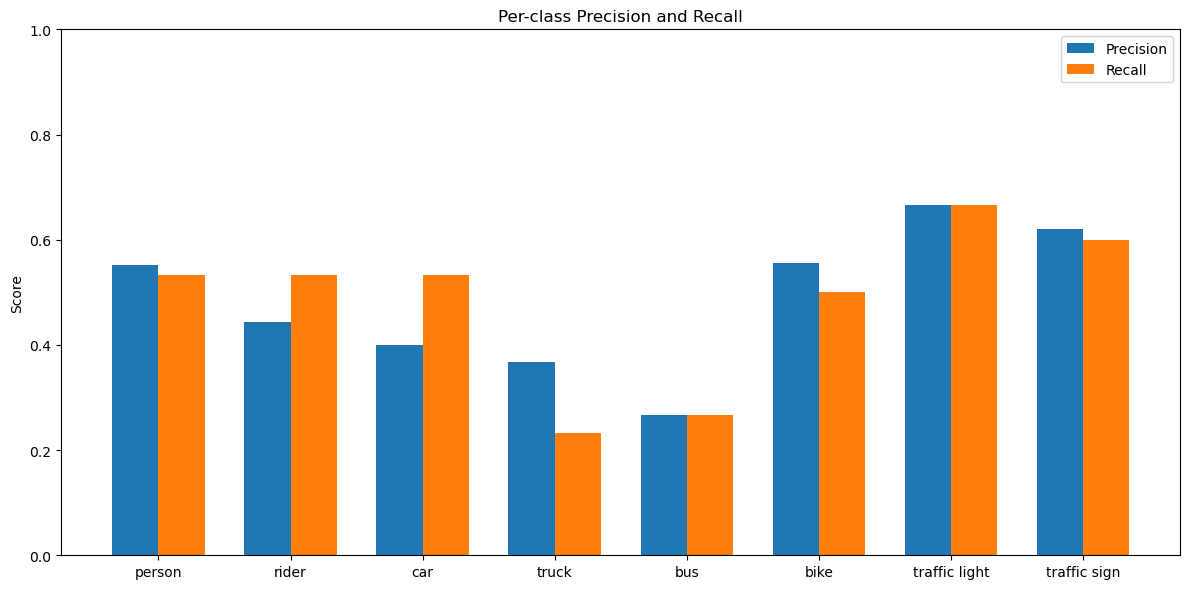

In [16]:
# Per class evaluation on the corrupted dataset (shuffled patches)
validation_data_loader = DataLoader(dataset=validate_dataset, batch_size=32)
per_class_precision_corrupted, per_class_recall_corrupted = evaluate_per_class(model, validation_data_loader, validate_dataset.classes, validate_dataset.labels, visualize=True)

# Model performs best for the "traffic_light" class with a precision and recall of 0.66
# Model performs worst for the "bus" class (precision=0.26, recall=0.26) and the "truck" class (precision=0.36, recall=0.23)  

Agregated metrics for corrupted dataset:

Macro precision: 0.4843
Macro recall:    0.4833

Agregated metrics for clean dataset:

Macro precision: 0.4843
Macro recall:    0.4833


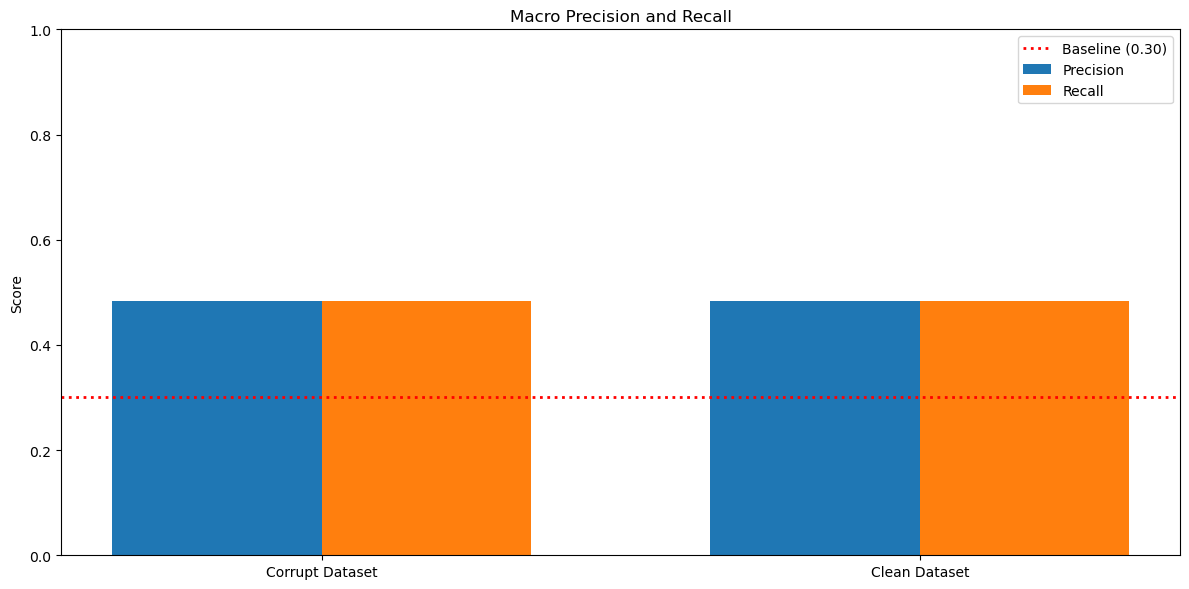

In [17]:
# Here, the agregated metrics are the same for both the corrupted dataset and the clean dataset.
# This means that the model is invariant to the positions of the patches, and as a result, predicts the
# same labels.
print("Agregated metrics for corrupted dataset:")
# Macro Prec = The mean per-class precision scores | Macro Recall = Same but for recall
macro_prec_corrupt, macro_recall_corrupt = agregate_per_class_metrics(per_class_precision_corrupted, per_class_recall_corrupted)

per_class_precision_clean, per_class_recall_clean = evaluate_per_class(model, test_data_loader, test_dataset.classes, test_dataset.labels)

print("\nAgregated metrics for clean dataset:")
macro_prec_clean, macro_recall_clean = agregate_per_class_metrics(per_class_precision_clean, per_class_recall_clean)

# Visualization
x = np.arange(2)
width = 0.35

precision_values = np.array([macro_prec_corrupt, macro_prec_clean])
recall_values = np.array([macro_recall_corrupt, macro_recall_clean])

plt.figure(figsize=(12, 6))

plt.bar(x - width / 2, precision_values, width, label="Precision")
plt.bar(x + width / 2, recall_values, width, label="Recall")
# Baseline of 0.3 as described by the task
plt.axhline(
    y=0.3,
    linestyle="dotted",
    linewidth=2,
    color="red",
    label=f"Baseline ({0.3:.2f})"
)

plt.xticks(x, ["Corrupt Dataset", "Clean Dataset"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Macro Precision and Recall")
plt.legend()
plt.tight_layout()

plt.savefig("macro_precision_recall_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 3 

In [ ]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass